In [1]:
## Import all the libraries

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# import seaborn
import seaborn as sns

from pandas.api.types import is_string_dtype

## all the functions to perform classification
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import export_graphviz

import statsmodels
import statsmodels.api as sm

import graphviz
import pydotplus
from IPython.display import Image

In [2]:
## set parameters
plt.rcParams['figure.figsize'] = [15,8]


In [3]:
## display complete dataframe
pd.options.display.max_columns = None
pd.options.display.max_rows = None
np.set_printoptions(suppress = True)

In [4]:
##read data
df_heart = pd.read_csv('HeartDisease.csv')
df_heart.head()

,age,gender,chest_pain,rest_bps,cholestrol,fasting_blood_sugar,rest_ecg,thalach,exer_angina,old_peak,slope,ca,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df_heart.shape

(303, 14)

In [6]:
## now we will understand the data
df_heart.dtypes

age                      int64
gender                   int64
chest_pain               int64
rest_bps                 int64
cholestrol               int64
fasting_blood_sugar      int64
rest_ecg                 int64
thalach                  int64
exer_angina              int64
old_peak               float64
slope                    int64
ca                       int64
thalassemia              int64
target                   int64
dtype: object

In [7]:
## since some of the columns have their datatypes wrong so we will correct them
for col in ['gender','chest_pain','fasting_blood_sugar','rest_ecg','exer_angina','slope','ca','thalassemia']:
    df_heart[col] = df_heart[col].astype('object')

In [8]:
df_heart.dtypes

age                      int64
gender                  object
chest_pain              object
rest_bps                 int64
cholestrol               int64
fasting_blood_sugar     object
rest_ecg                object
thalach                  int64
exer_angina             object
old_peak               float64
slope                   object
ca                      object
thalassemia             object
target                   int64
dtype: object

In [9]:
## we will divide them into features and target
df_features = df_heart.drop('target', axis = 1)
df_target = df_heart['target']

In [10]:
## now we get the statistics for numerical features
df_features.describe()

,age,rest_bps,cholestrol,thalach,old_peak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.623762,246.264026,149.646865,1.039604
std,9.082101,17.538143,51.830751,22.905161,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,47.500000,120.000000,211.000000,133.500000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000
75%,61.000000,140.000000,274.500000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


In [11]:
## statistics for categorical features
df_features.describe(include = 'object')

,gender,chest_pain,fasting_blood_sugar,rest_ecg,exer_angina,slope,ca,thalassemia
count,303,303,303,303,303,303,303,303
unique,2,4,2,3,2,3,5,4
top,1,0,0,1,0,2,0,2
freq,207,143,258,152,204,142,175,166


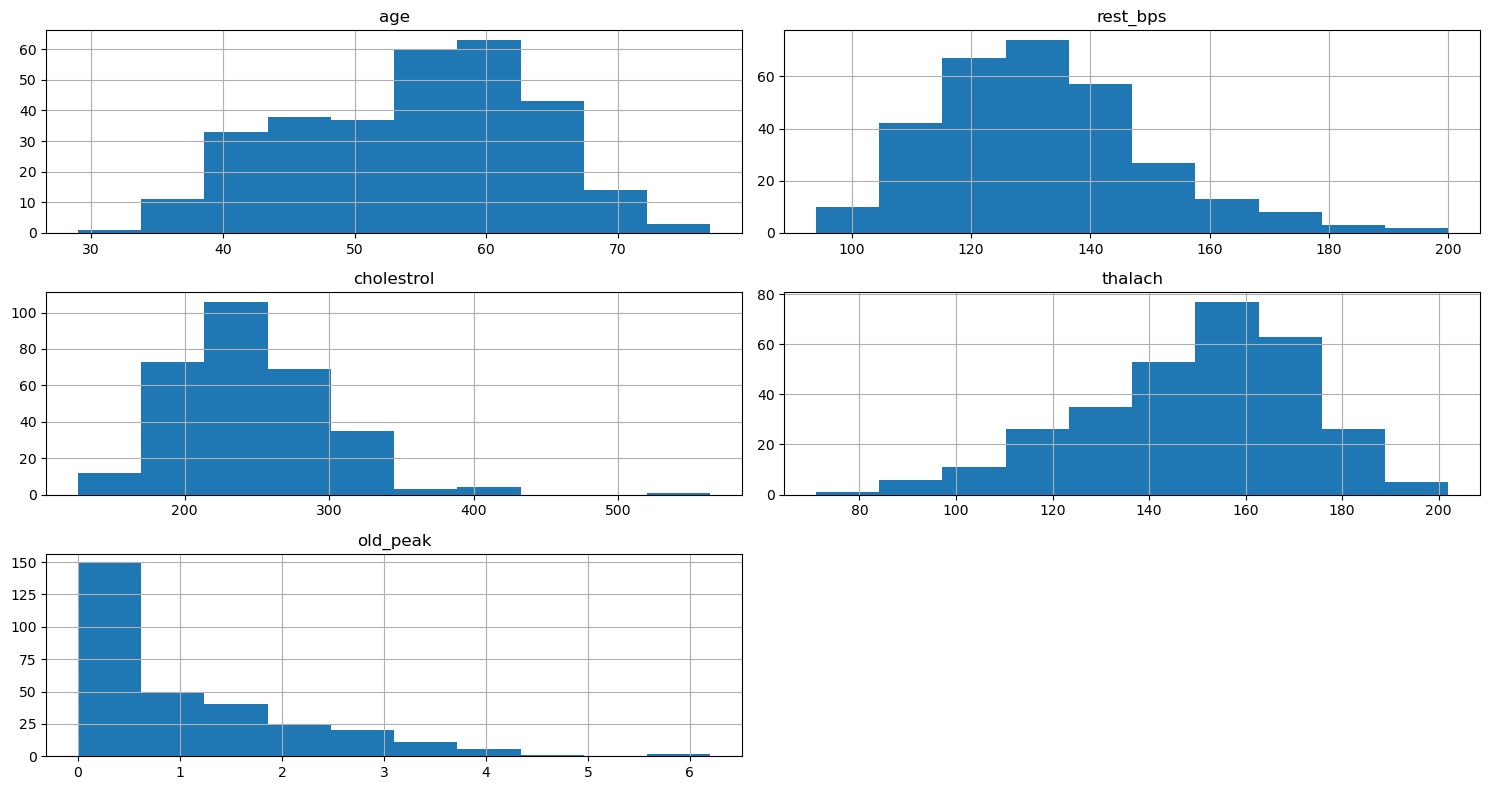

In [12]:
## distribution of nnumeric independent variables visually
df_features.hist()
plt.tight_layout()

plt.show()


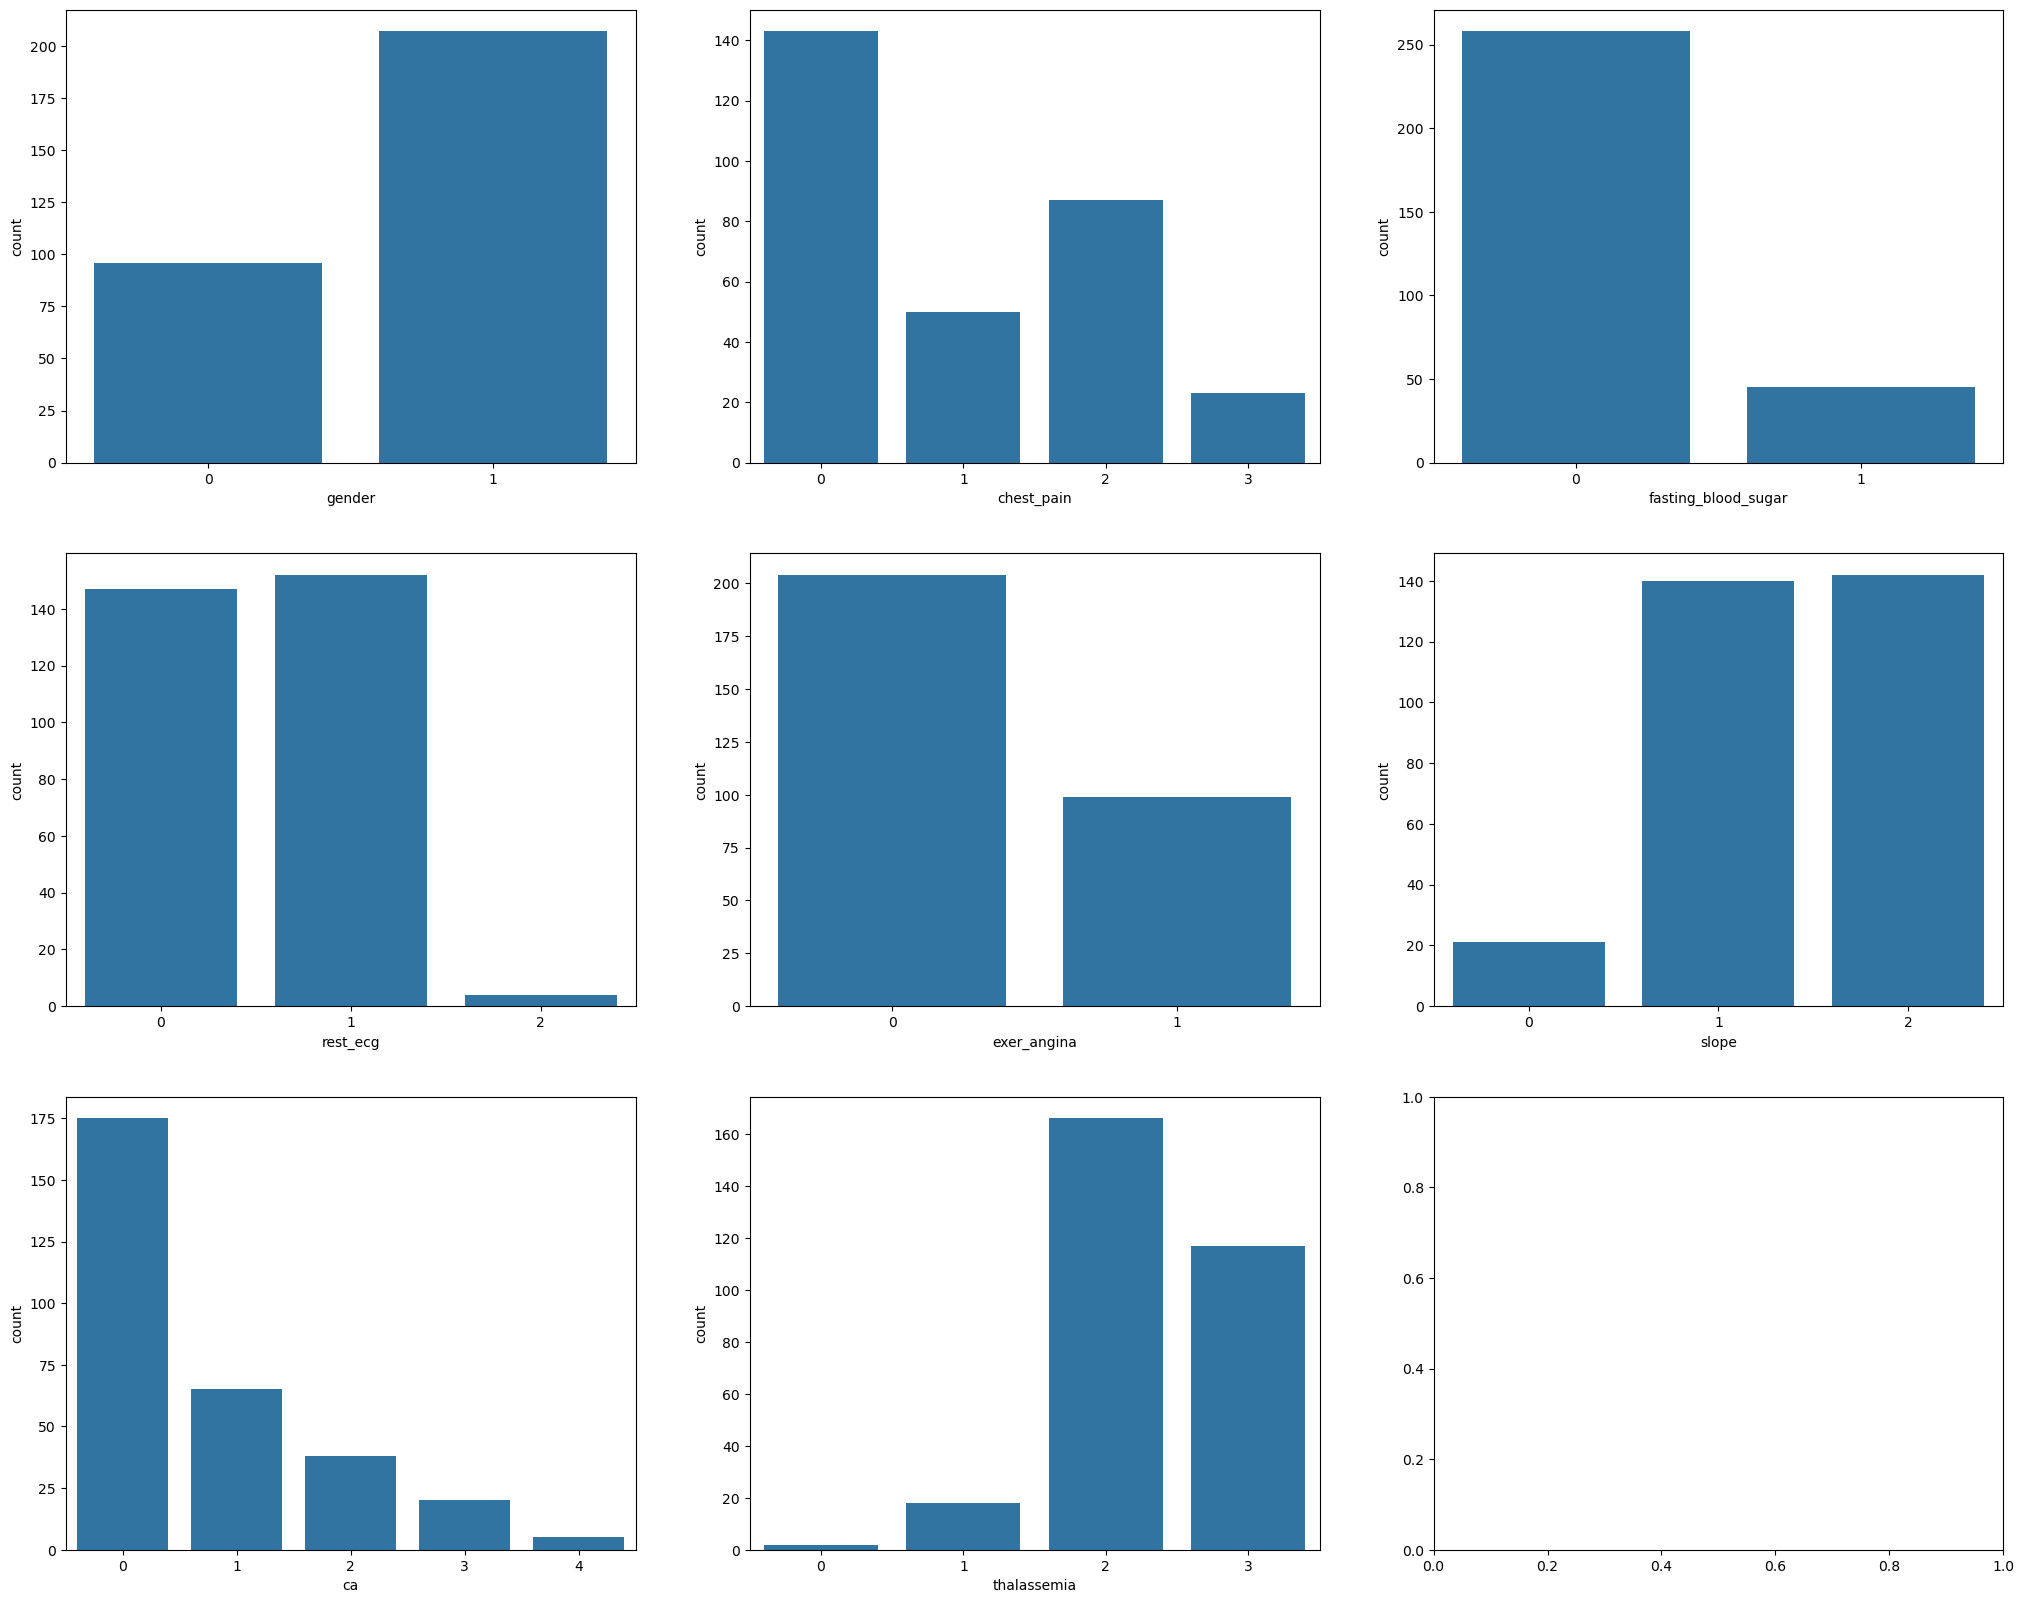

In [13]:
## visualizing the categorical variables in the independent variable list
categorical = df_features.select_dtypes(include = ['object', 'category']).columns.tolist()

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(25, 20))

# use a for loop to plot the count plot for each variable
for variable, subplot in zip(categorical, ax.flatten()):
    
    # use countplot() to plot the graph
    # pass the axes for the plot to the parameter, 'ax'
    sns.countplot(data =  df_features, x =variable, ax=subplot)

# display the plot
plt.show()

In [14]:
## distribution of dependent variable
class_frequency = df_heart.target.value_counts()
class_frequency

target
1    165
0    138
Name: count, dtype: int64

In [15]:
## now we find the correlation
corr = df_features.corr()
corr

,age,gender,chest_pain,rest_bps,cholestrol,fasting_blood_sugar,rest_ecg,thalach,exer_angina,old_peak,slope,ca,thalassemia
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001
gender,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041
chest_pain,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736
rest_bps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210
cholestrol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803
fasting_blood_sugar,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019
rest_ecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439
exer_angina,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754
old_peak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244


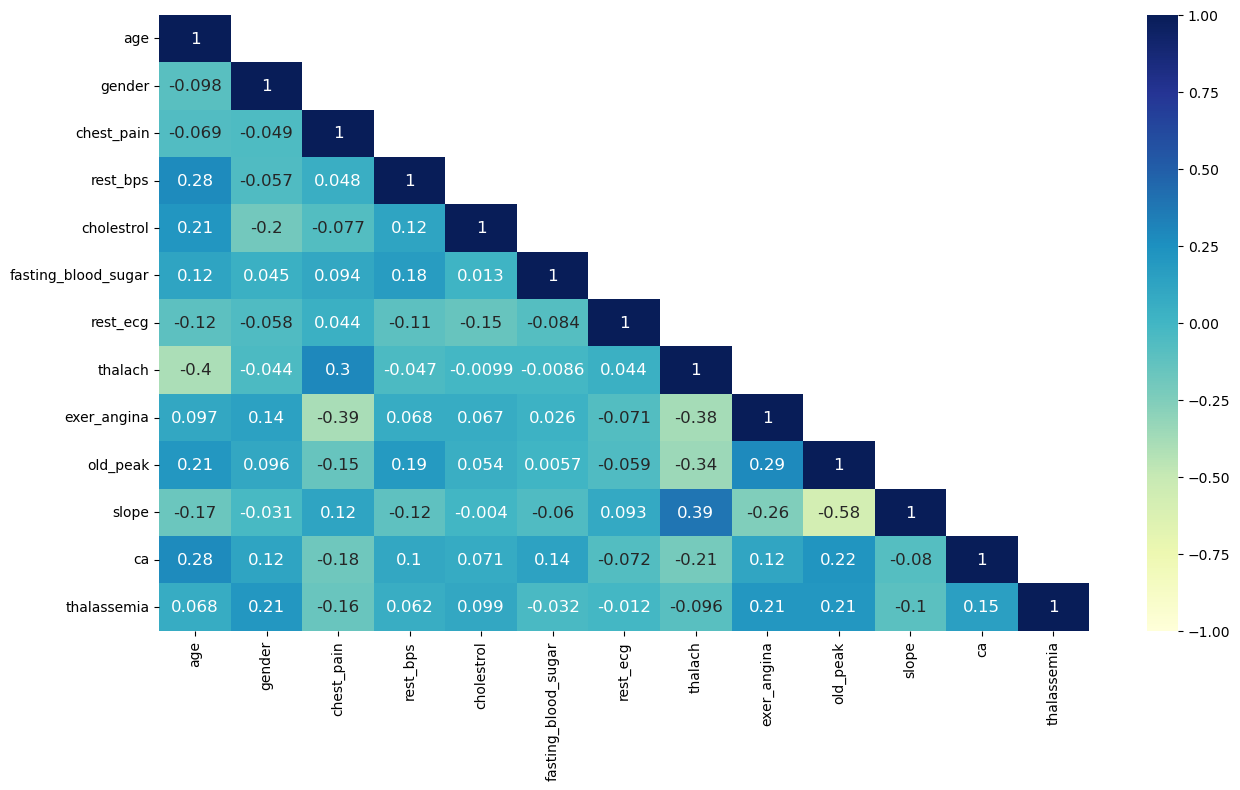

In [16]:
## we will plot a heatmmap to visualize thhe correlation better
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(corr, cmap = 'YlGnBu', vmax = 1.0, vmin = -1.0, annot = True, annot_kws = {'size':12}, mask = mask)
plt.show()

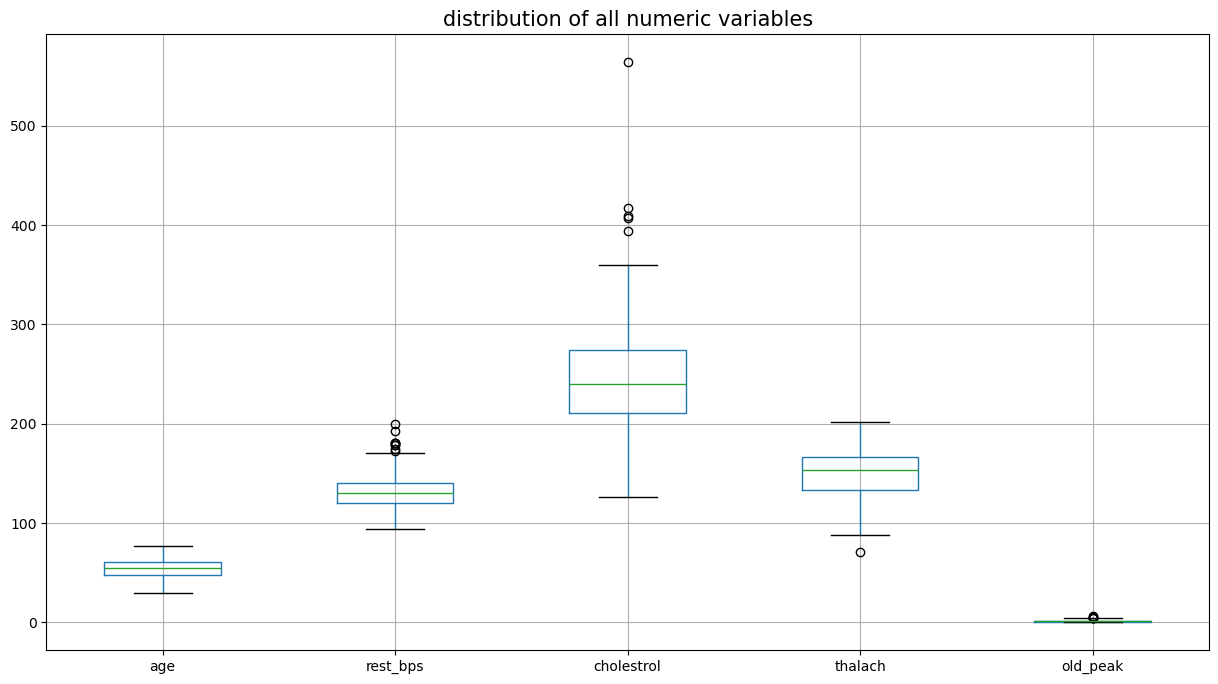

In [17]:
## now we have to find the outliers using a boxplot
df_features.boxplot()

plt.title('distribution of all numeric variables', fontsize = 15)

plt.show()

In [18]:
##we have few outliers so we need to remove them with IQR

Q1 = df_features.quantile(0.25)

Q3 = df_features.quantile(0.75)

IQR = Q3-Q1

print(IQR)

age                    13.5
gender                  1.0
chest_pain              2.0
rest_bps               20.0
cholestrol             63.5
fasting_blood_sugar     0.0
rest_ecg                1.0
thalach                32.5
exer_angina             1.0
old_peak                1.6
slope                   1.0
ca                      1.0
thalassemia             1.0
dtype: object


In [19]:
mask = ~((df_heart[df_features.columns] < (Q1 - 1.5 * IQR)) | 
           (df_heart[df_features.columns] > (Q3 + 1.5 * IQR))).any(axis = 1)

df_heart = df_heart[mask].reset_index(drop = True)

In [20]:
df_heart.shape

(228, 14)

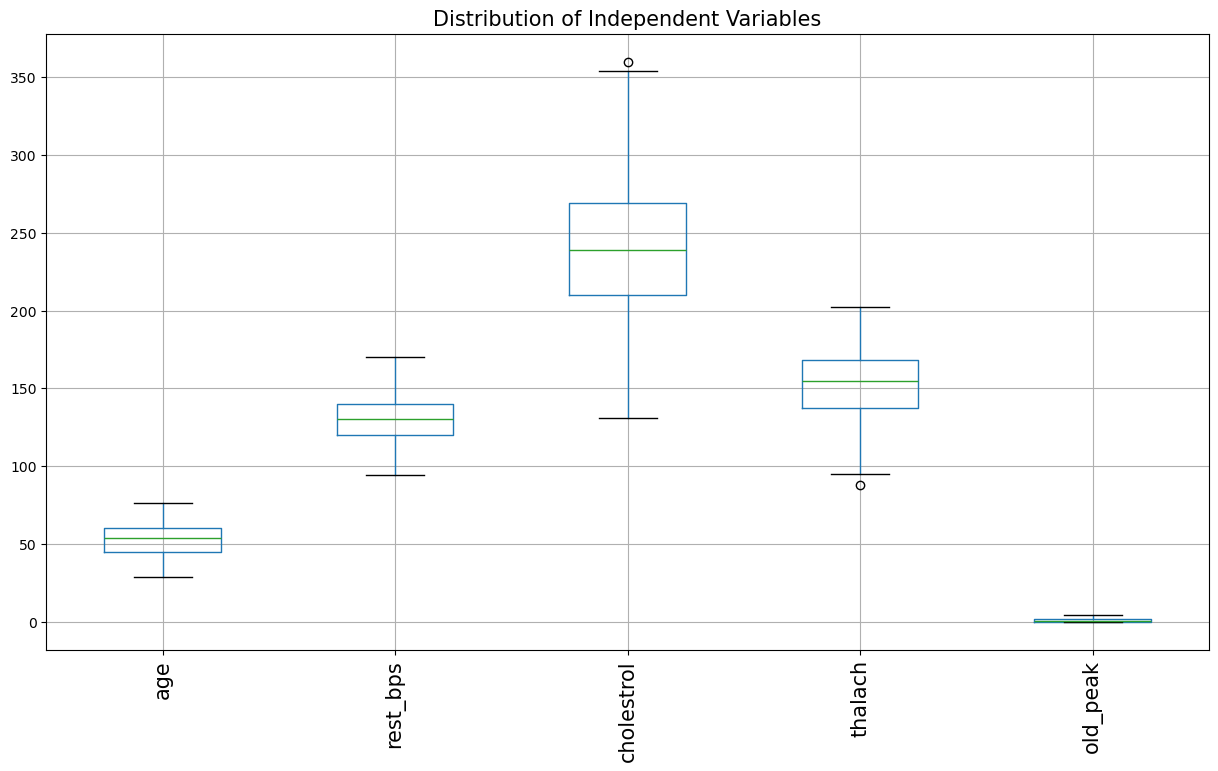

In [21]:
## we will check the outliers again
# make a list of numerical features without considering the 'white corpuscle'
cols = ['age','rest_bps','cholestrol','thalach','old_peak']

# plot multiple boxplots
df_heart[cols].boxplot()

# set plot label
# set text size using 'fontsize'
plt.title('Distribution of Independent Variables', fontsize = 15)

# xticks() returns the x-axis ticks
# 'rotation = vertical' rotates the x-axis labels vertically
plt.xticks(rotation = 'vertical', fontsize = 15)

# display the plot
plt.show()

In [22]:
df_heart.shape

(228, 14)

In [23]:
## finding the missing values
total = df_heart.isnull().sum().sort_values(ascending = False)
total

age                    0
gender                 0
chest_pain             0
rest_bps               0
cholestrol             0
fasting_blood_sugar    0
rest_ecg               0
thalach                0
exer_angina            0
old_peak               0
slope                  0
ca                     0
thalassemia            0
target                 0
dtype: int64

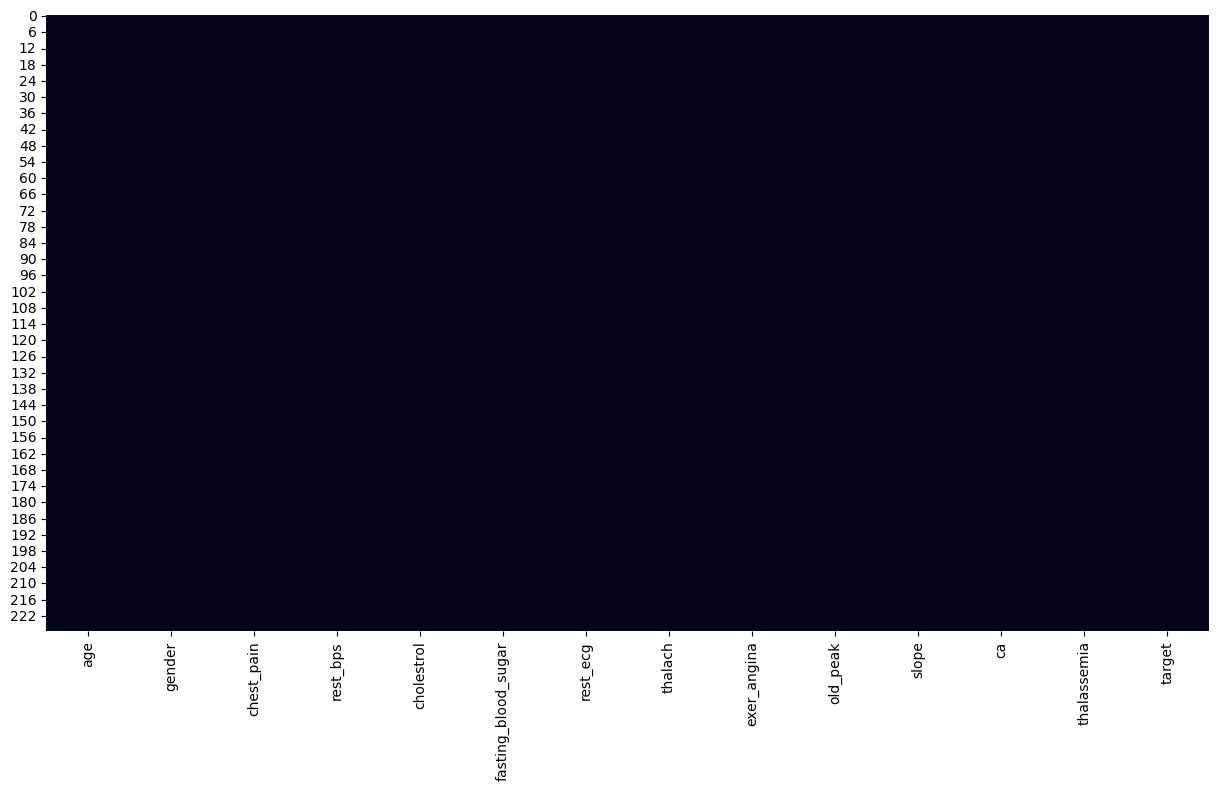

In [24]:
## visualizzing the missing values
sns.heatmap(df_heart.isnull(), cbar = False )
plt.show()

In [25]:
## since we do not have any missing values so we do not need to treat it 

In [26]:
## Now we will prepare the data for further steps
## we will separate the categorical and numerical features
df_cat = df_heart[categorical]

df_num = df_heart.drop(categorical, axis = 1)

In [27]:
df_cat.shape, df_num.shape

((228, 8), (228, 6))

In [28]:
## now we will dummy encode the categorical data stored in df_cat
df_cat_dummy = pd.get_dummies(df_cat,drop_first = True)

In [29]:
df_cat_dummy.shape

(228, 13)

In [30]:
df_cat_dummy.head()

,gender_1,chest_pain_1,chest_pain_2,chest_pain_3,rest_ecg_1,rest_ecg_2,exer_angina_1,slope_1,slope_2,ca_1,ca_2,thalassemia_2,thalassemia_3
0,True,False,True,False,True,False,False,False,False,False,False,True,False
1,False,True,False,False,False,False,False,False,True,False,False,True,False
2,True,True,False,False,True,False,False,False,True,False,False,True,False
3,False,False,False,False,True,False,True,False,True,False,False,True,False
4,True,False,False,False,True,False,False,True,False,False,False,False,False


In [31]:
df_heart_dummy = pd.concat([df_num, df_cat_dummy], axis = 1)
df_heart_dummy.head()

,age,rest_bps,cholestrol,thalach,old_peak,target,gender_1,chest_pain_1,chest_pain_2,chest_pain_3,rest_ecg_1,rest_ecg_2,exer_angina_1,slope_1,slope_2,ca_1,ca_2,thalassemia_2,thalassemia_3
0,37,130,250,187,3.5,1,True,False,True,False,True,False,False,False,False,False,False,True,False
1,41,130,204,172,1.4,1,False,True,False,False,False,False,False,False,True,False,False,True,False
2,56,120,236,178,0.8,1,True,True,False,False,True,False,False,False,True,False,False,True,False
3,57,120,354,163,0.6,1,False,False,False,False,True,False,True,False,True,False,False,True,False
4,57,140,192,148,0.4,1,True,False,False,False,True,False,False,True,False,False,False,False,False


In [32]:
df_heart_dummy.shape

(228, 19)

In [33]:
y = pd.DataFrame(df_heart_dummy['target'])
x = df_heart_dummy.drop('target', axis = 1)

In [34]:
x.head()

,age,rest_bps,cholestrol,thalach,old_peak,gender_1,chest_pain_1,chest_pain_2,chest_pain_3,rest_ecg_1,rest_ecg_2,exer_angina_1,slope_1,slope_2,ca_1,ca_2,thalassemia_2,thalassemia_3
0,37,130,250,187,3.5,True,False,True,False,True,False,False,False,False,False,False,True,False
1,41,130,204,172,1.4,False,True,False,False,False,False,False,False,True,False,False,True,False
2,56,120,236,178,0.8,True,True,False,False,True,False,False,False,True,False,False,True,False
3,57,120,354,163,0.6,False,False,False,False,True,False,True,False,True,False,False,True,False
4,57,140,192,148,0.4,True,False,False,False,True,False,False,True,False,False,False,False,False


In [35]:
y.head()

,target
0,1
1,1
2,1
3,1
4,1


In [36]:
## now we will make the generalized functions for each of our performance parameters


In [37]:
def get_test_report(model):
    return(classification_report(y_test,y_pred))

In [38]:
def kappa_score(model):
    return (cohen_kappa_score(y_test,y_pred))

In [39]:
## plot the confusion matrix
def plot_confusion_matrix(model):
    cm = confusion_matrix(y_test, y_pred)

    conf_matrix = pd.DataFrame(data = cm, columns = ['predicted:0', 'predicted:1'], index = ['actual:0', 'actual:1'])

    sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = ListedColormap(['lightskyblue']), cbar = False,
               linewidths = 0.1, annot_kws = {'size': 25})
    plt.xticks(fontsize = 20)
    plt.yticks(fontsize = 20)

    plt.show()

In [40]:
## define roc_curve
def plot_roc(model):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    plt.plot(fpr,tpr)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])

    plt.plot([0,1],[0,1], 'r--')
    plt.title('roc curve for heart desease classifier', fontsize = 15)
    plt.text(x = 0.02, y = 0.9, s = ('Auc score:', round(roc_auc_score(y_test, y_pred),4)))
    plt.grid(True)

In [41]:
from sklearn import metrics
score_card = pd.DataFrame(columns = ['Model', 'Auc score', 'precion score','recall score', 'accuracy score', 
                                    'kappa score', 'f1-score'])
def update_score_card(model_name):
    global score_card
    new_result = pd.DataFrame([{'Model': model_name,
                               'Auc score': roc_auc_score(y_test, y_pred_prob),
                               'precision score': metrics.precision_score(y_test,y_pred),
                               'recall score': metrics.recall_score(y_test,y_pred),
                               'accuracy score': metrics.accuracy_score(y_test,y_pred),
                               'kappa score': cohen_kappa_score(y_test,y_pred),
                               'f1-score': metrics.f1_score(y_test,y_pred)}])
    score_card = pd.concat([score_card, new_result], ignore_index = True)
    return score_card

In [42]:
## now we have a good data so we can move towards makinng the model
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.30, random_state = 10)

print('x_trian', x_train.shape)
print('y_train', y_train.shape)
print('x_test', x_test.shape)
print('y_test', y_test.shape)

x_trian (159, 18)
y_train (159, 1)
x_test (69, 18)
y_test (69, 1)


In [43]:
## we will use this unscaled data for this first model
decision_tree = DecisionTreeClassifier(criterion = 'entropy', random_state = 10)
decision_tree_model = decision_tree.fit(x_train,y_train)

In [44]:
## here we will check the importance of the features
importance = decision_tree_model.feature_importances_

for i,v in enumerate(importance):
    print('feature: {}, score: {}'.format(i,round(v, 3)))

feature: 0, score: 0.175
feature: 1, score: 0.062
feature: 2, score: 0.082
feature: 3, score: 0.152
feature: 4, score: 0.092
feature: 5, score: 0.055
feature: 6, score: 0.017
feature: 7, score: 0.0
feature: 8, score: 0.018
feature: 9, score: 0.013
feature: 10, score: 0.0
feature: 11, score: 0.0
feature: 12, score: 0.013
feature: 13, score: 0.012
feature: 14, score: 0.056
feature: 15, score: 0.03
feature: 16, score: 0.0
feature: 17, score: 0.223


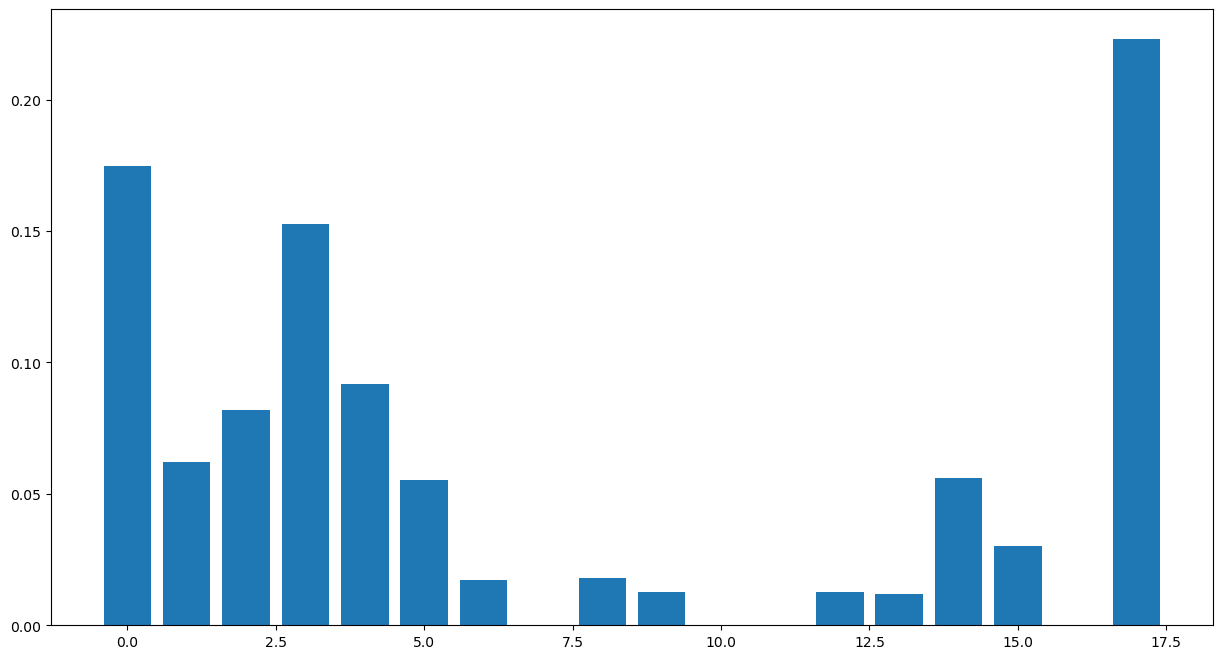

In [45]:
## now we will visualize the importance
from matplotlib import pyplot
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

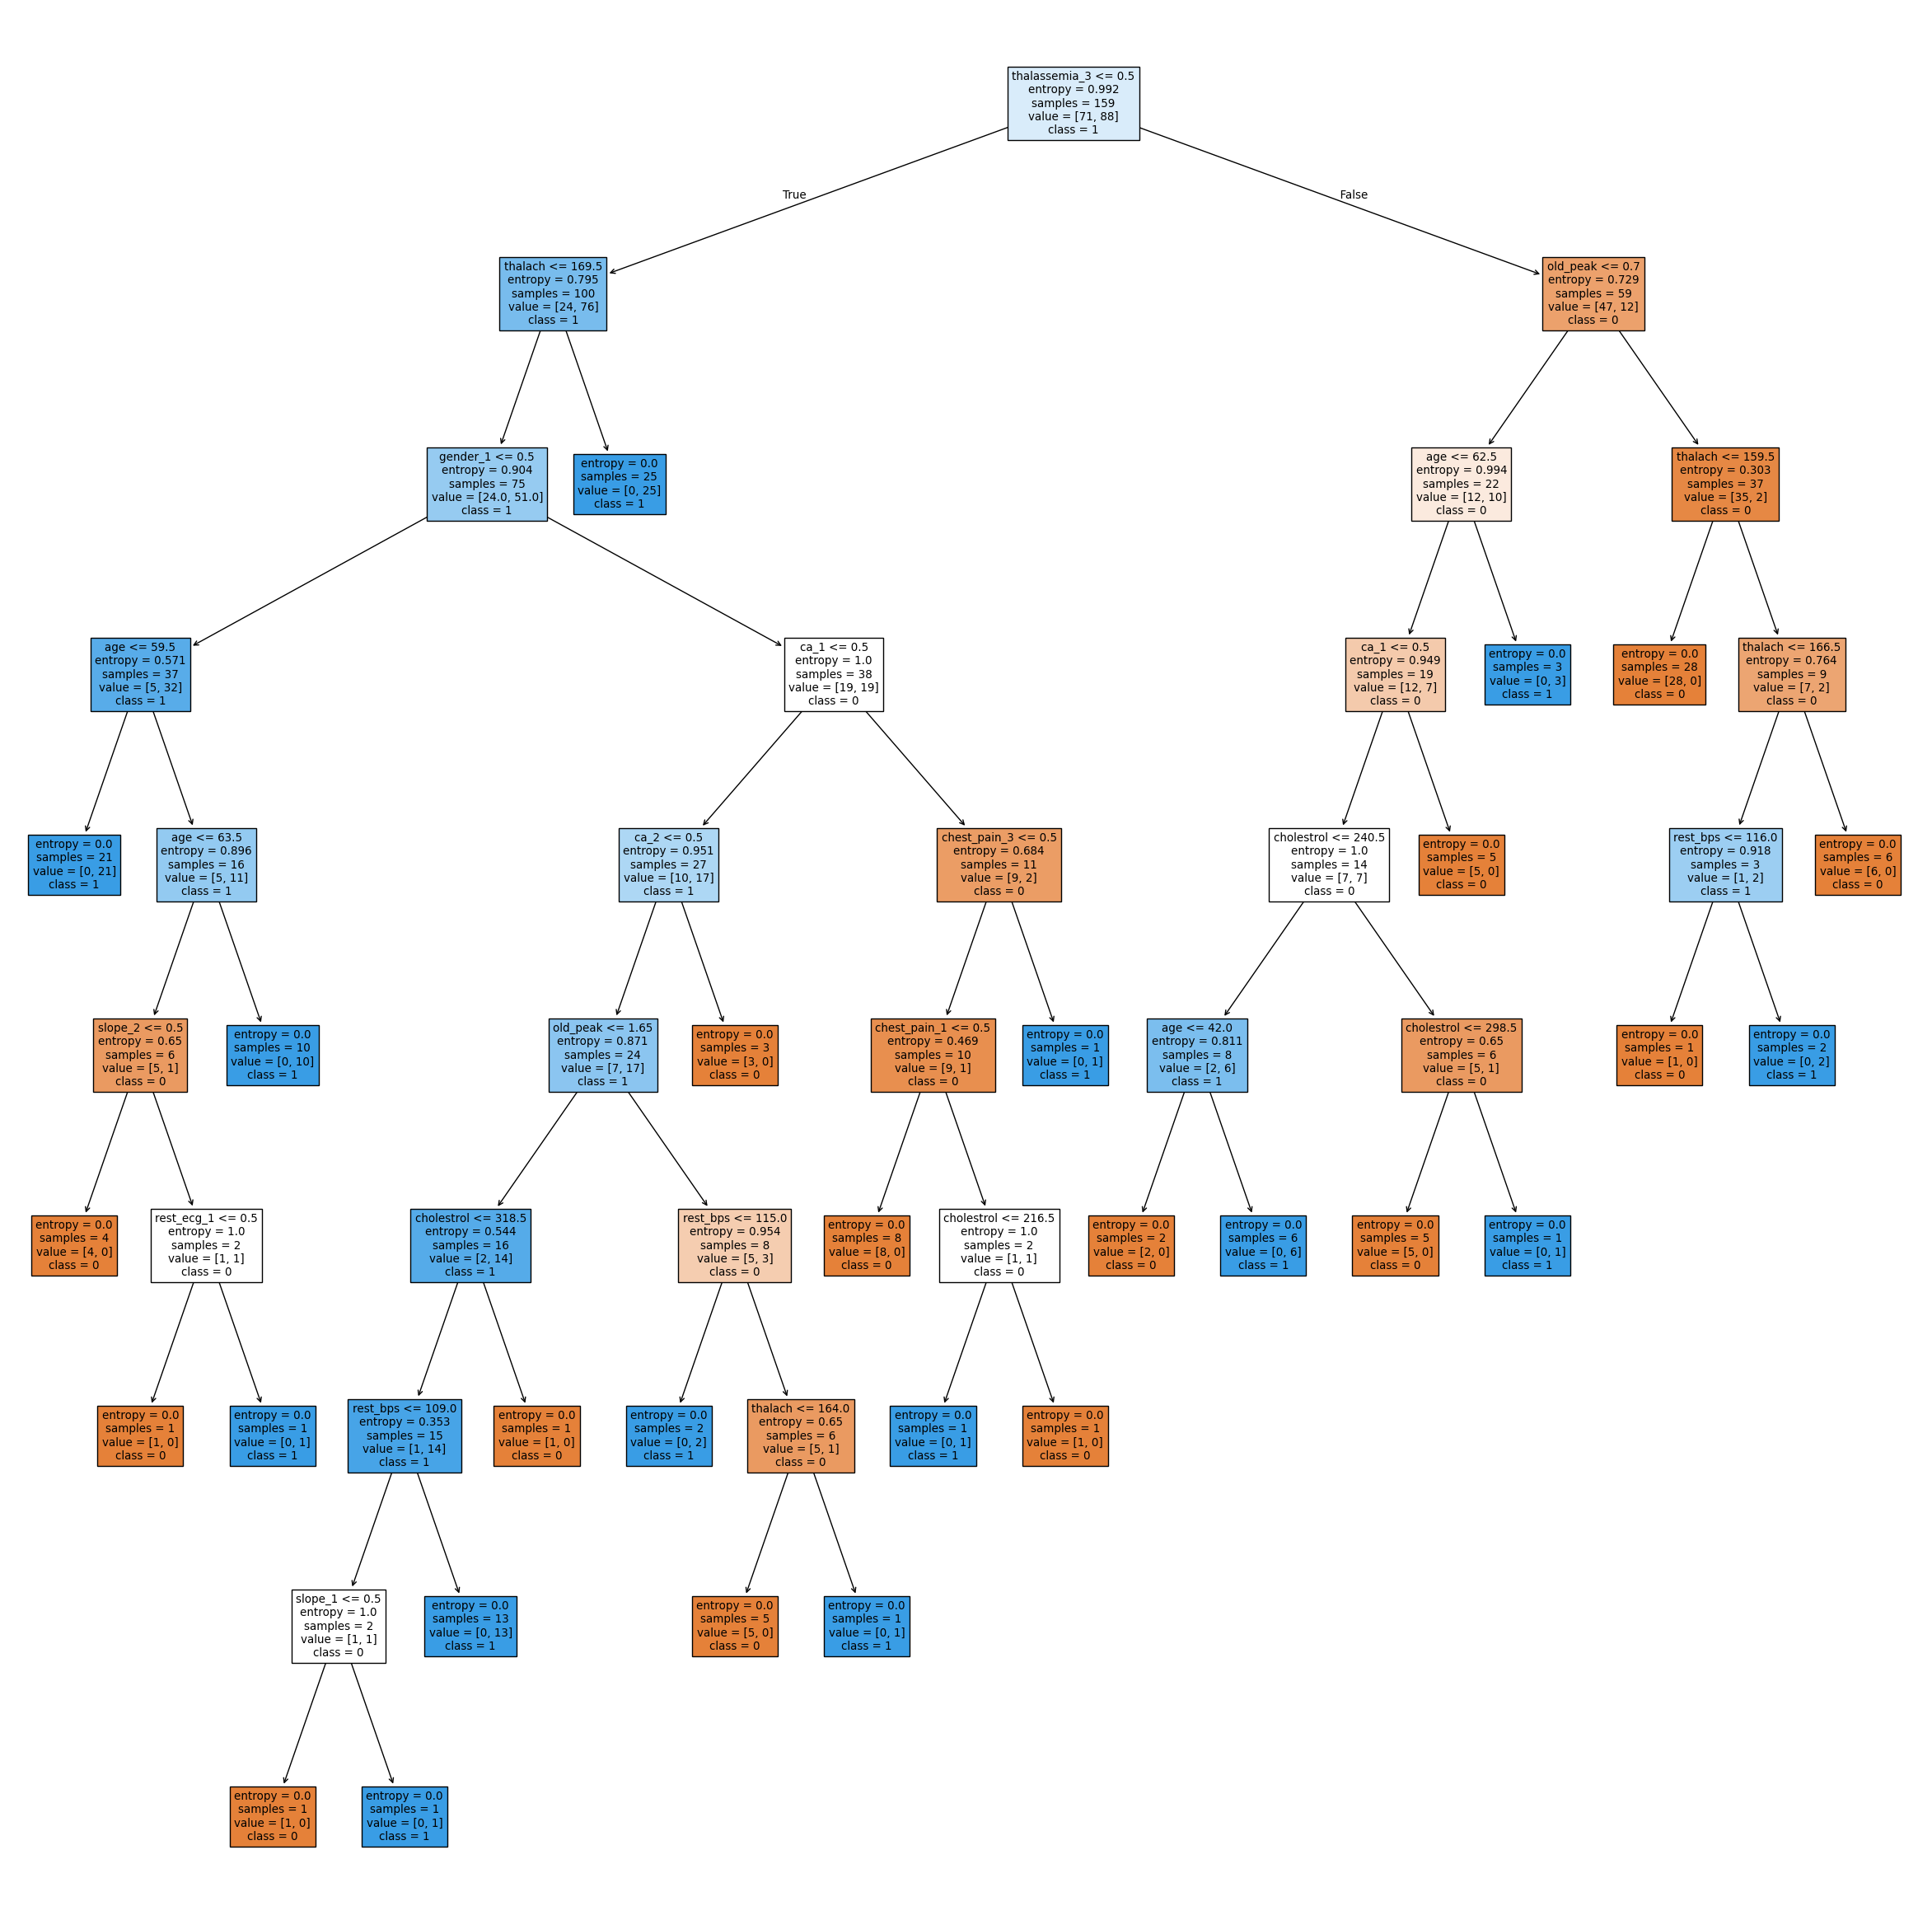

In [46]:
## now we will plot the decision tree
from sklearn import tree
# save the column names in 'labels'
lables = x_train.columns

# plot the decision tree 
fig = plt.figure(figsize=(30,30))
_ = tree.plot_tree(decision_tree_model, 
                   feature_names=lables,  
                   class_names=["0","1"],
                   filled=True)

In [47]:
## now we will do the predictions
## this step is necessary because some of the metrics require probability input
y_pred_prob = decision_tree_model.predict_proba(x_test)[:,1]

In [48]:
y_pred_prob

array([1., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 1., 0., 1., 0., 0., 1.,
       1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1.,
       0., 0., 0., 1., 1., 0., 0., 1., 1., 1., 0., 0., 1., 1., 1., 0., 1.,
       1., 0., 1., 0., 1., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 0., 0.,
       1.])

In [49]:
y_pred = decision_tree_model.predict(x_test)

In [50]:
y_pred

array([1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1], dtype=int64)

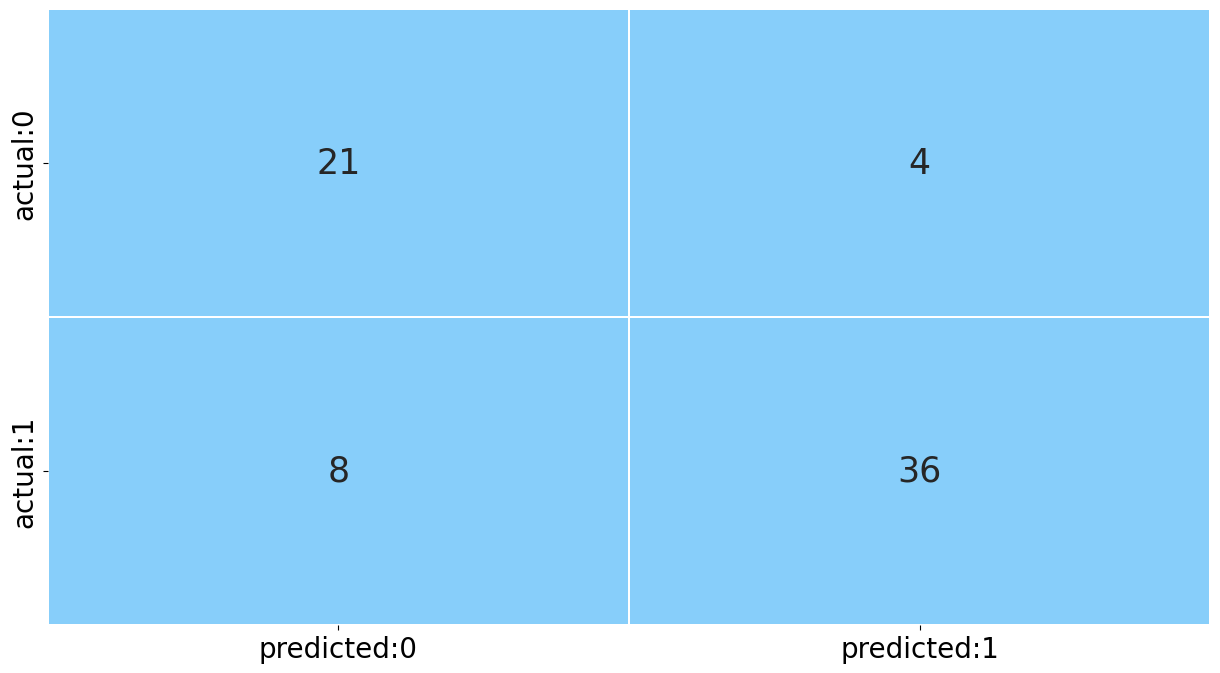

In [51]:
## build the confusion matrix
plot_confusion_matrix(decision_tree_model)

In [52]:
## now we calculate all the performance measures
test_report = get_test_report(decision_tree_model)

print(test_report)

              precision    recall  f1-score   support

           0       0.72      0.84      0.78        25
           1       0.90      0.82      0.86        44

    accuracy                           0.83        69
   macro avg       0.81      0.83      0.82        69
weighted avg       0.84      0.83      0.83        69



In [53]:
kappa_value = kappa_score(decision_tree_model)
print(kappa_value)

0.6362038664323375


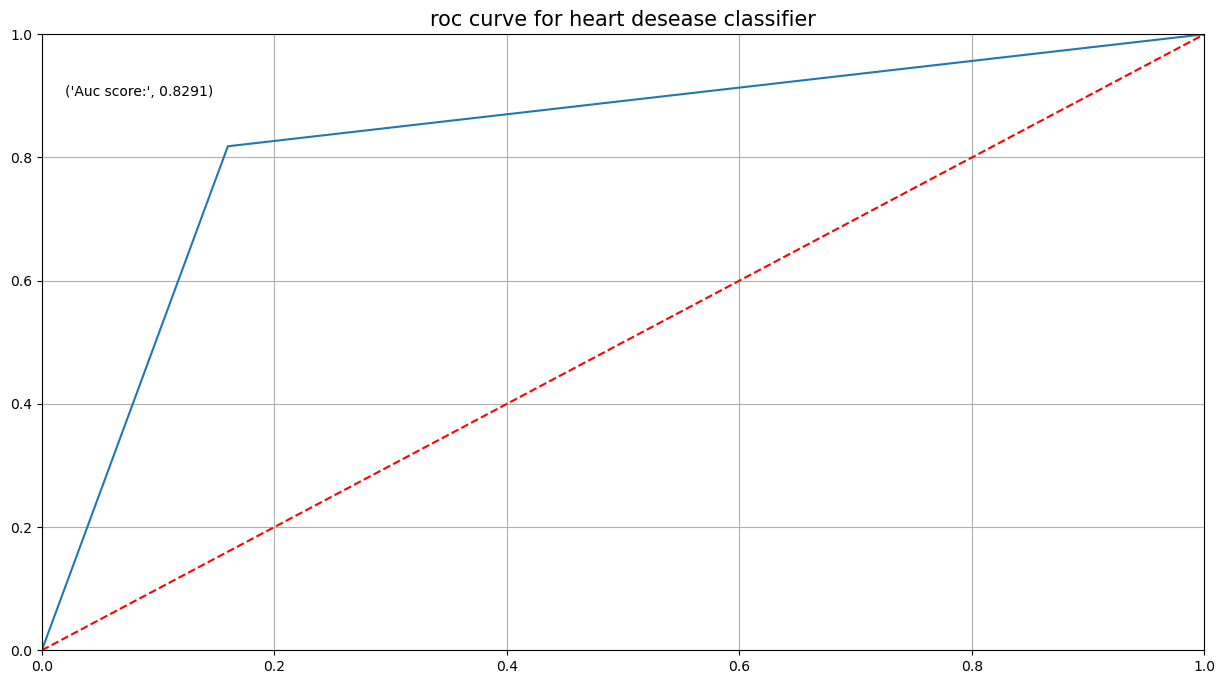

In [54]:
## plot the roc_curve
plot_roc(decision_tree_model)

In [55]:
## finally we will tabulate the result
update_score_card(model_name = 'decision_tree_model')

,Model,Auc score,precion score,recall score,accuracy score,kappa score,f1-score,precision score
0,decision_tree_model,0.829091,NaN,0.818182,0.826087,0.636204,0.857143,0.9


## Now we will prune the tree

In [56]:
prune = DecisionTreeClassifier(max_depth = 5, max_leaf_nodes = 25, random_state = 10)

decision_tree_prune = prune.fit(x_train,y_train)

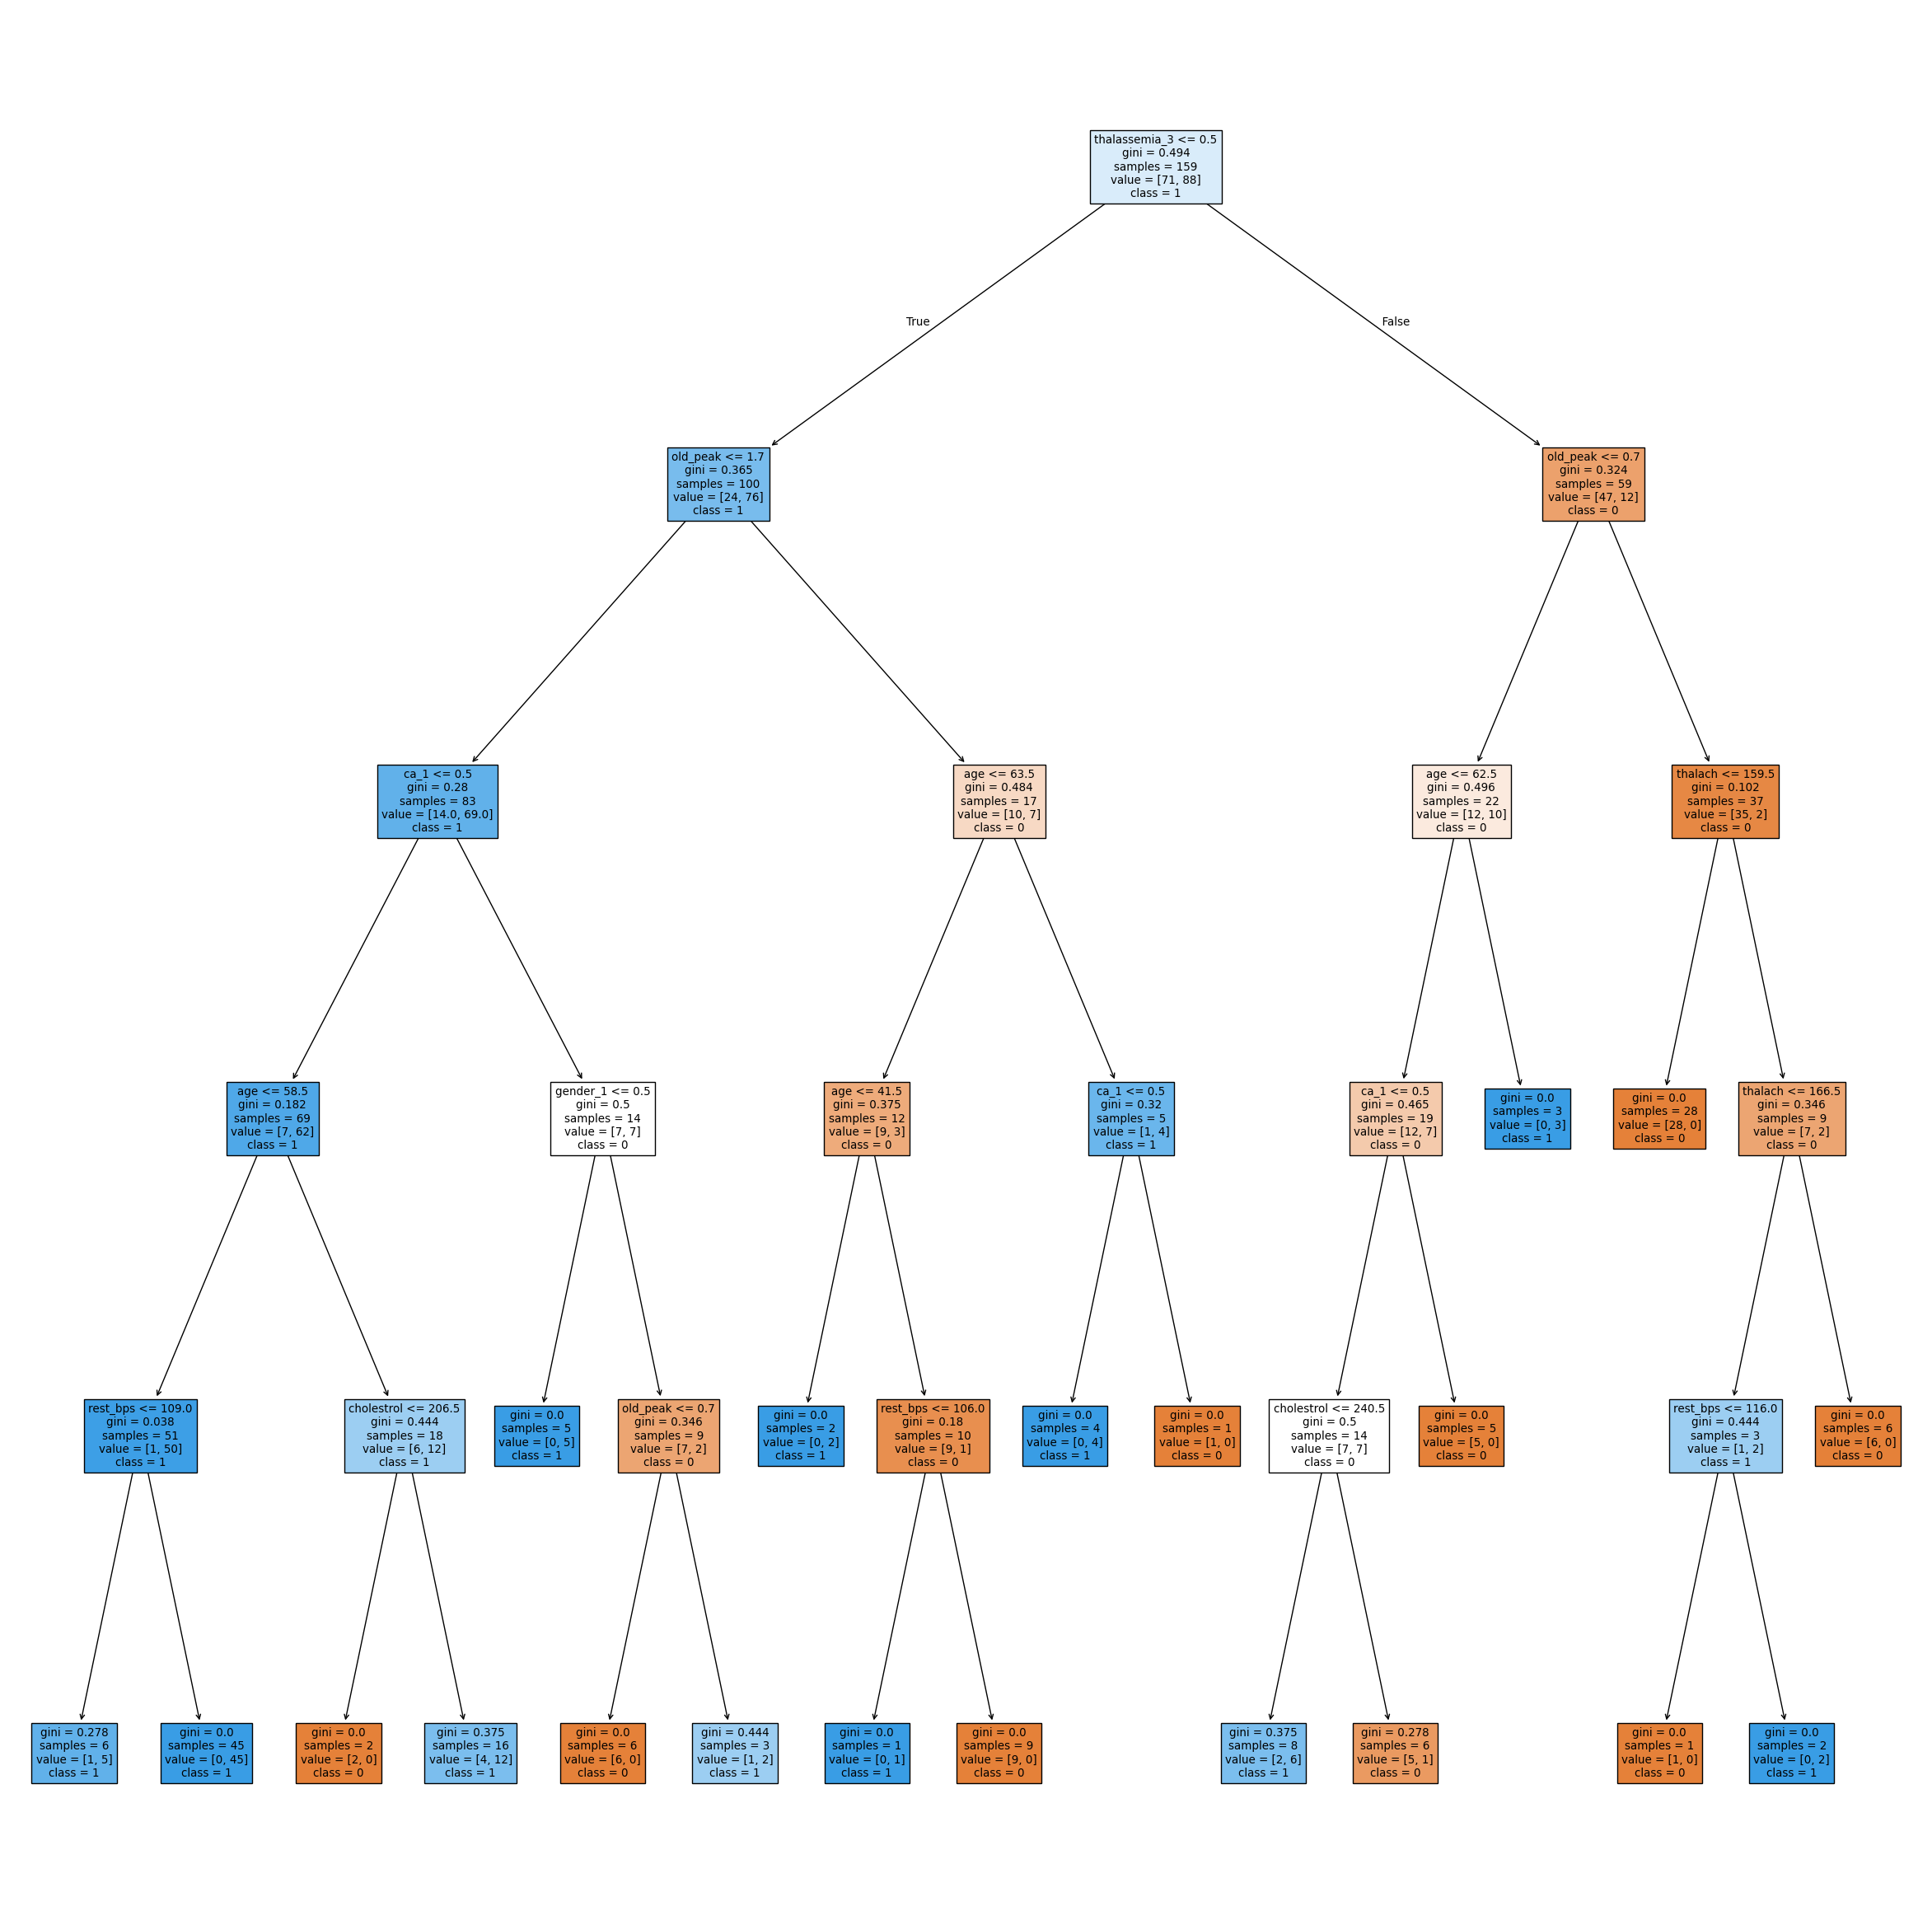

In [57]:
## plot the tree
lables = x_train.columns

fig = plt.figure(figsize = (30,30))
_ = tree.plot_tree(decision_tree_prune,
                  feature_names = lables,
                  class_names = ['0','1'],
                  filled = True)

In [58]:
## do the prediction
y_pred_prob = decision_tree_prune.predict_proba(x_test)[:,1]

In [59]:
y_pred = decision_tree_prune.predict(x_test)

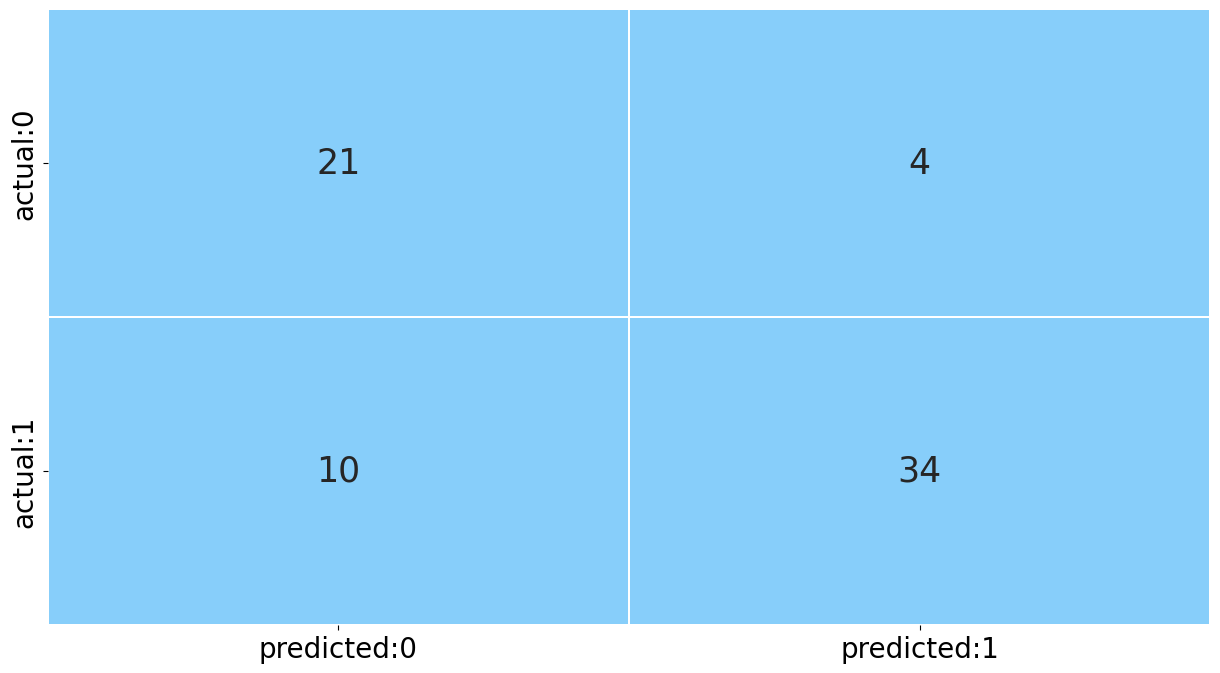

In [60]:
## plot the confusion matrix
plot_confusion_matrix(decision_tree_prune)

In [61]:
## no find all the performance measures
test_report = get_test_report(decision_tree_prune)
print(test_report)

              precision    recall  f1-score   support

           0       0.68      0.84      0.75        25
           1       0.89      0.77      0.83        44

    accuracy                           0.80        69
   macro avg       0.79      0.81      0.79        69
weighted avg       0.82      0.80      0.80        69



In [62]:
## find the kappa score
kappa_value = kappa_score(decision_tree_prune)
print(kappa_value)

0.5825410544511668


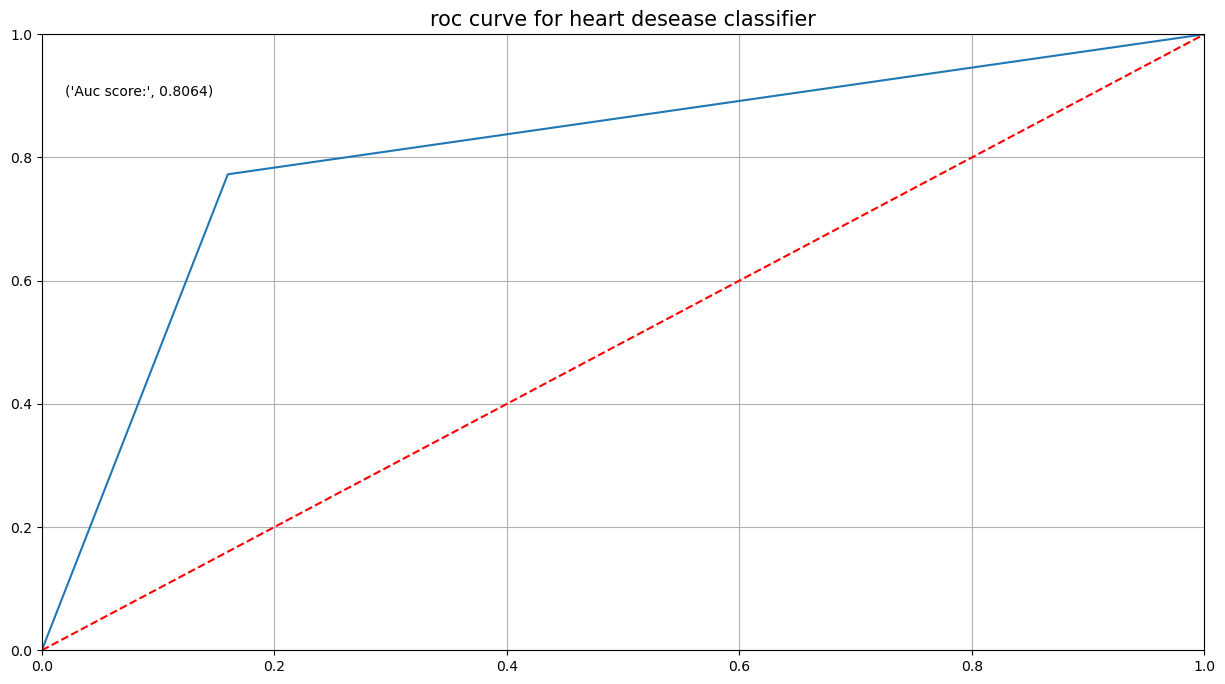

In [63]:
## plot the roc_curve
plot_roc(decision_tree_prune)

In [64]:
## finally we will tabulate the result 
update_score_card(model_name = 'Decision tree (pruned)')

,Model,Auc score,precion score,recall score,accuracy score,kappa score,f1-score,precision score
0,decision_tree_model,0.829091,NaN,0.818182,0.826087,0.636204,0.857143,0.900000
1,Decision tree (pruned),0.850000,NaN,0.772727,0.797101,0.582541,0.829268,0.894737


In [65]:
## now we will use the grid search cv to find the best hyper parameters
tuned_parameters = [{'criterion': ['gini','entropy'],
                    'min_samples_split': [10,20,30],
                    'max_depth': [3,5,7,9],
                    'min_samples_leaf': [15,20,25,30,35],
                    'max_leaf_nodes': [5,10,15,20,25]}]

In [66]:
decision_tree_classification = DecisionTreeClassifier(random_state = 10)

grid = GridSearchCV(estimator= decision_tree_classification,
                    param_grid = tuned_parameters,
                    cv = 10)
dt_grid = grid.fit(x_train, y_train)
print('best hyper parameters for the decision tree classifier is :', dt_grid.best_params_)

best hyper parameters for the decision tree classifier is : {'criterion': 'gini', 'max_depth': 3, 'max_leaf_nodes': 5, 'min_samples_leaf': 25, 'min_samples_split': 10}


In [67]:
dt_grid_model = DecisionTreeClassifier(criterion = dt_grid.best_params_.get('criterion'),
                                      max_depth = dt_grid.best_params_.get('max_depth'),
                                      max_leaf_nodes = dt_grid.best_params_.get('max_leaf_nodes'),
                                      min_samples_split = dt_grid.best_params_.get('min_samples_split'),
                                      min_samples_leaf = dt_grid.best_params_.get('min_samples_leaf'),
                                      random_state = 10)
dt_grid_model = dt_grid_model.fit(x_train, y_train)

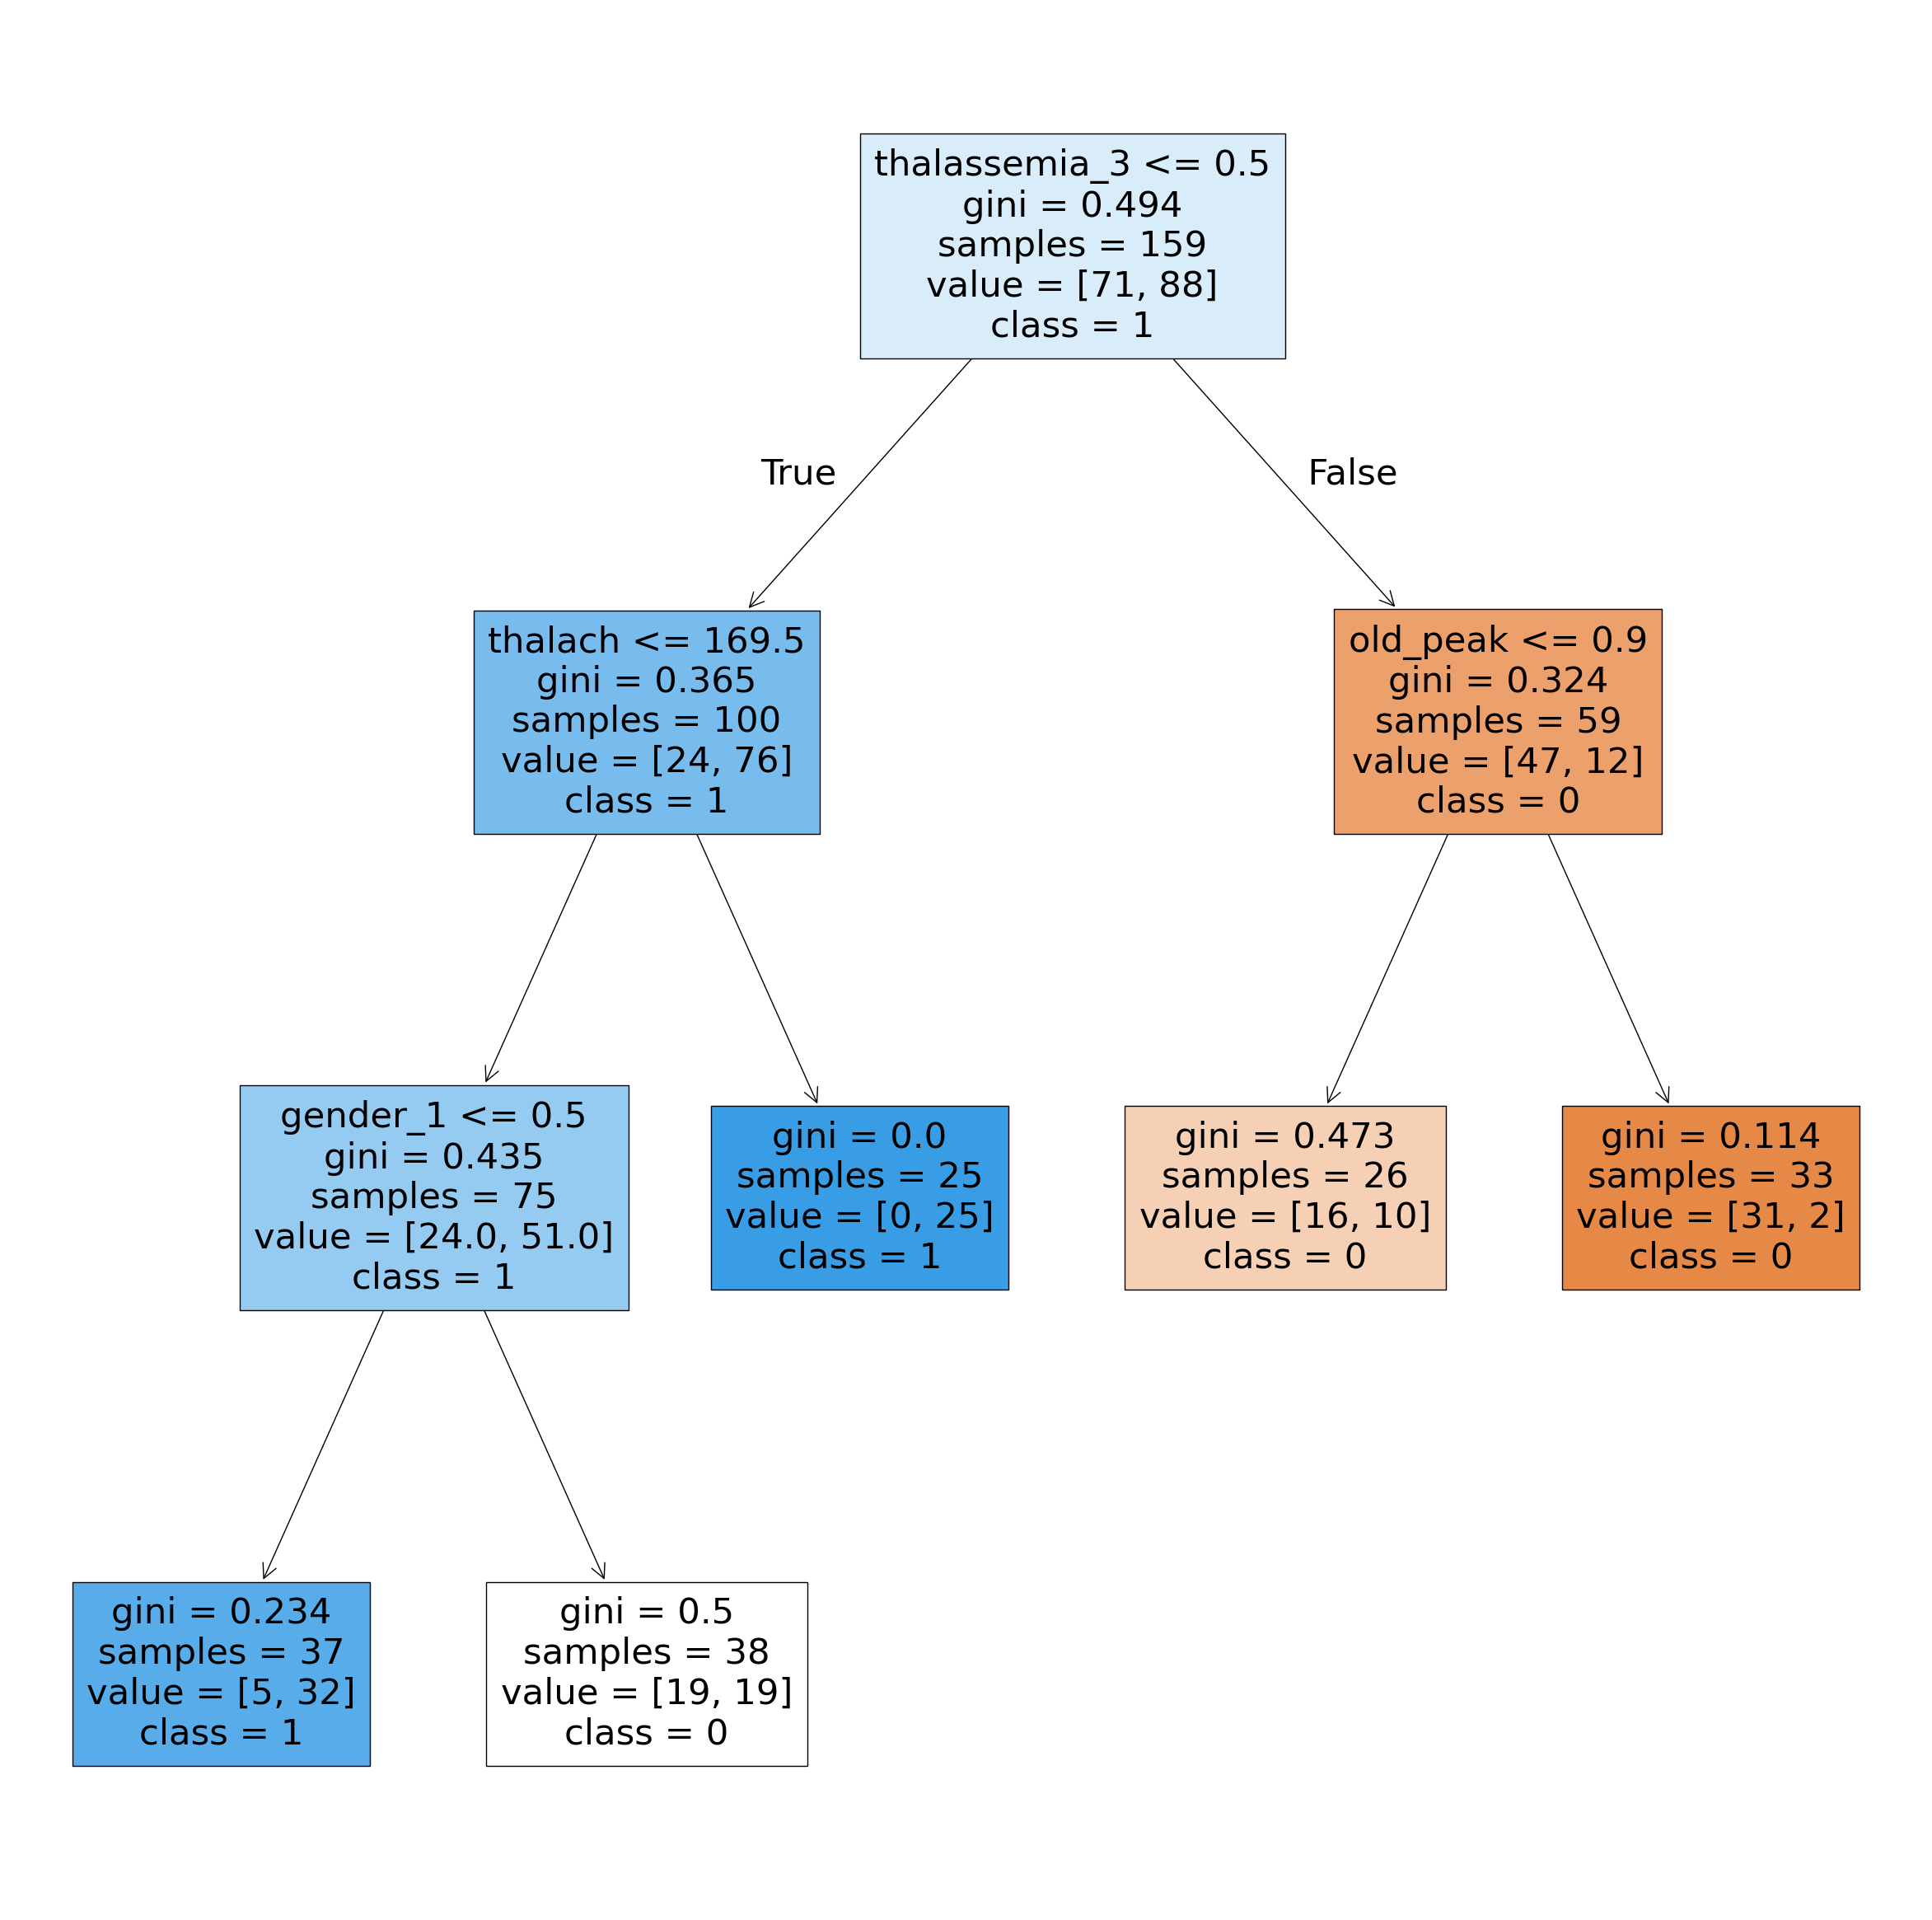

In [68]:
lables = x_train.columns
fig = plt.figure(figsize = (30,30))
_=tree.plot_tree(dt_grid_model,
                feature_names = lables,
                class_names = ['0','1'],
                filled = True)

In [69]:
y_pred_prob = dt_grid_model.predict_proba(x_test)[:,1]

In [70]:
y_pred = dt_grid_model.predict(x_test)

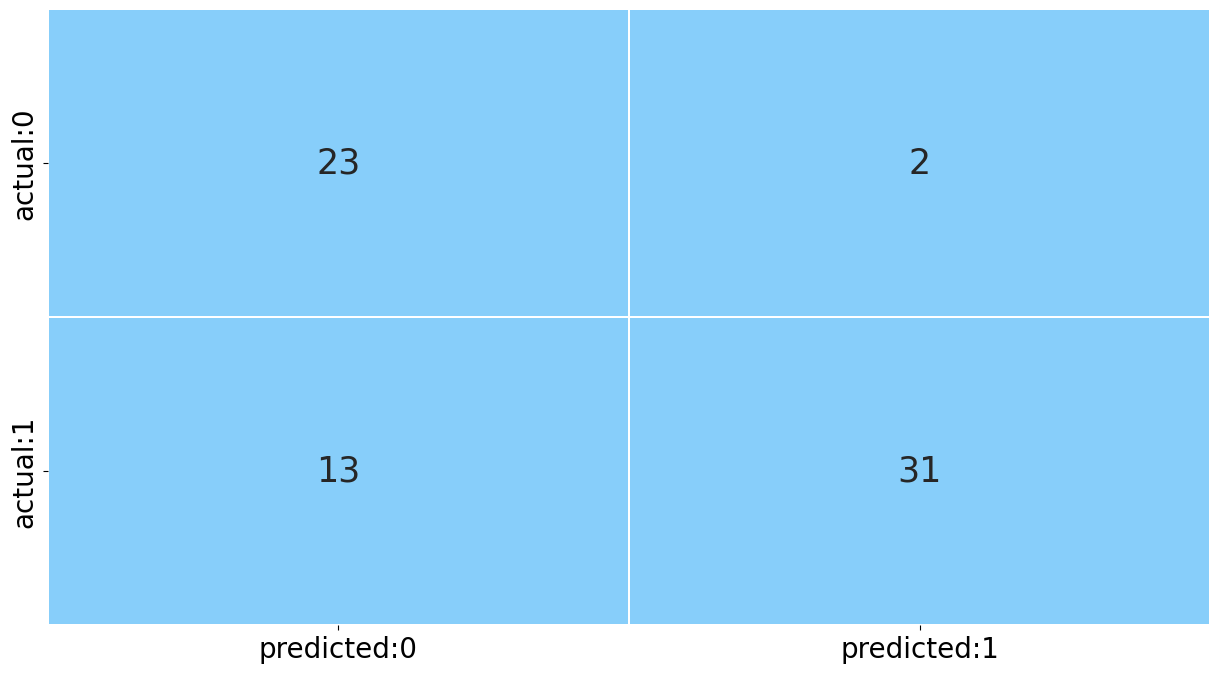

In [71]:
## build the confusion matrix
plot_confusion_matrix(dt_grid_model)

In [72]:
## get the test report
test_report = get_test_report(dt_grid_model)
print(test_report)

              precision    recall  f1-score   support

           0       0.64      0.92      0.75        25
           1       0.94      0.70      0.81        44

    accuracy                           0.78        69
   macro avg       0.79      0.81      0.78        69
weighted avg       0.83      0.78      0.79        69



In [73]:
## get the kappa score
kappa_value = kappa_score(dt_grid_model)
print(kappa_value)

0.5703611457036114


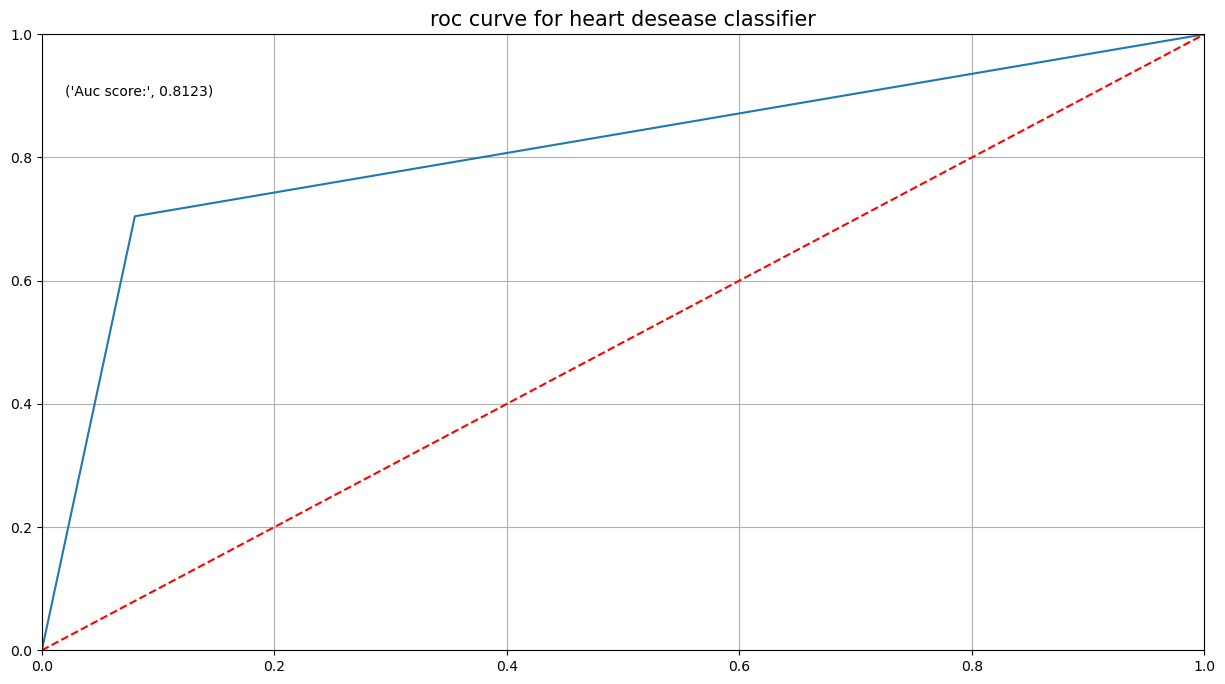

In [74]:
## now we plot the roc curve
plot_roc(dt_grid_model)

In [75]:
## now the final tabulation
update_score_card(model_name = 'Decision tree (grid)')

,Model,Auc score,precion score,recall score,accuracy score,kappa score,f1-score,precision score
0,decision_tree_model,0.829091,NaN,0.818182,0.826087,0.636204,0.857143,0.900000
1,Decision tree (pruned),0.850000,NaN,0.772727,0.797101,0.582541,0.829268,0.894737
2,Decision tree (grid),0.867727,NaN,0.704545,0.782609,0.570361,0.805195,0.939394
